In [48]:
# 1 데이터 불러오기
import yfinance as yf

ticks = yf.Ticker('005930.KS')
df = ticks.history(start='2000-01-01')


In [49]:
# 2 데이터 전처리
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)


WINDOW = 30


# 전체 데이터에서 30일 윈도우 생성 (X, y)
def make_dataset(dataset, window=WINDOW):
    X, y = [], []
    for i in range(len(dataset) - window):
        X.append(dataset[i:i+window])       # 30일간 모든 피처
        y.append(dataset[i+window][3])      # 다음 날 'Close' (인덱스 3)
    return np.array(X), np.array(y)

X, y = make_dataset(scaled, WINDOW)

# 70% train, 15% valid, 15% test
n = len(X)
train_end = int(n * 0.7)
valid_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_valid, y_valid = X[train_end:valid_end], y[train_end:valid_end]
X_test,  y_test  = X[valid_end:], y[valid_end:]


In [50]:
# 3 모델 구축
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers


model = keras.Sequential([
    layers.Input(shape=(WINDOW, X.shape[2])),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# 4 모델 학습
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=100,
    batch_size=32,
    callbacks=[es, rlr],
    verbose=1
)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0024 - mae: 0.0289 - val_loss: 6.5435e-04 - val_mae: 0.0174 - learning_rate: 0.0010
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 3.6970e-04 - mae: 0.0131 - val_loss: 0.0011 - val_mae: 0.0237 - learning_rate: 0.0010
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 2.9290e-04 - mae: 0.0113 - val_loss: 0.0014 - val_mae: 0.0262 - learning_rate: 0.0010
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 2.7553e-04 - mae: 0.0109 - val_loss: 8.8234e-04 - val_mae: 0.0217 - learning_rate: 0.0010
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 2.5425e-04 - mae: 0.0104 - val_loss: 0.0016 - val_mae: 0.0289 - learning_rate: 0.0010
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1.9749e-04 - mae: 0.0092 - val_loss: 0.0014 - val_mae: 0.0264 - learning_rate: 0.0010
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1.9188e-04 - mae: 0.0087 - val_loss: 8.0781e-0

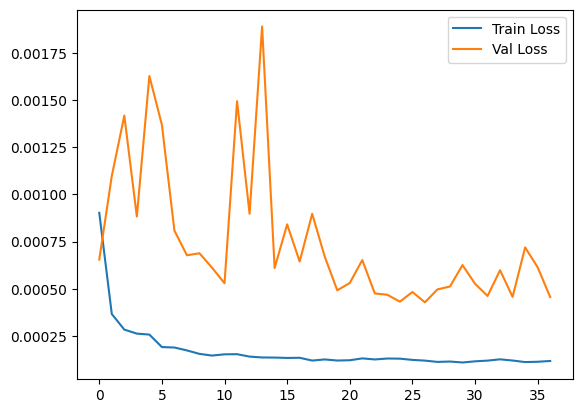

In [52]:
# 5 결과 시각화
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


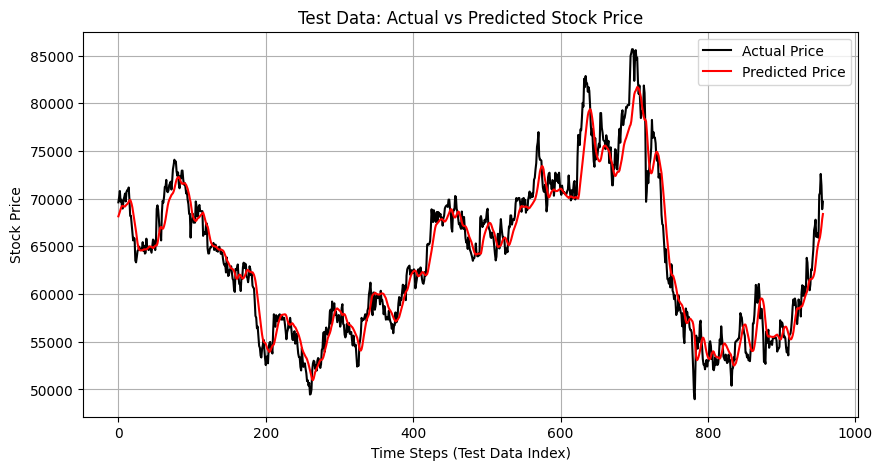

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 테스트 데이터 예측
y_pred_scaled = model.predict(X_test)

# 2. 역변환 (스케일링 해제)
n_features = X_test.shape[2]  # 피처 개수
temp_pred = np.zeros((len(y_pred_scaled), n_features))
temp_true = np.zeros((len(y_test), n_features))

close_index = 3
temp_pred[:, close_index] = y_pred_scaled[:, 0]
temp_true[:, close_index] = y_test

y_pred = scaler.inverse_transform(temp_pred)[:, close_index]
y_true = scaler.inverse_transform(temp_true)[:, close_index]

# 3. 비교 그래프
plt.figure(figsize=(10, 5))
plt.plot(y_true, label='Actual Price', color='black')
plt.plot(y_pred, label='Predicted Price', color='red')
plt.title("Test Data: Actual vs Predicted Stock Price")
plt.xlabel("Time Steps (Test Data Index)")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 1503.01, RMSE: 1986.15
